In [4]:
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from pathlib import Path

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [6]:
CLASS_NAMES = [
    "asteroid",
    "black_hole",
    "earth",
    "galaxy",
    "jupiter",
    "mars",
    "mercury",
    "neptune",
    "pluto",
    "saturn",
    "uranus",
    "venus"
]

print(CLASS_NAMES)

['asteroid', 'black_hole', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [14]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=len(CLASS_NAMES)):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)


    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)

        return x

In [ ]:
MODEL_PATH = Path("../models/simple_cnn.pth")

model = SimpleCNN(
    num_classes=len(CLASS_NAMES)
)
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.to(device)
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [18]:
IMAGE_PATH = Path(
    "../datasets/raw/astro_dataset_maxia/test/galaxy/galaxy_024.jpg"
)

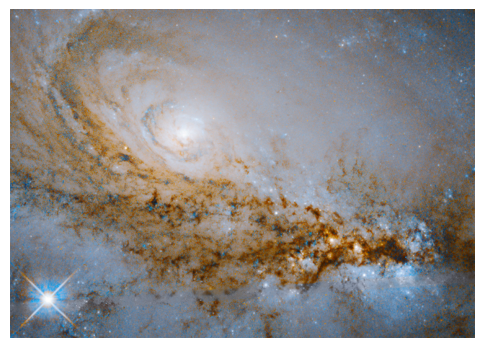

In [26]:
image = Image.open(IMAGE_PATH).convert("RGB")
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
input_tensor = transform(image)
input_tensor = input_tensor.unsqueeze(0)
input_tensor = input_tensor.to(device)
print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    confidence, prediction = torch.max(
        probabilities,
        dim=1
    )

In [22]:
print("=" * 40)
print(f"Prediction : {CLASS_NAMES[prediction.item()]}")
print(f"Confidence : {confidence.item()*100:.2f}%")
print("=" * 40)

Prediction : galaxy
Confidence : 99.98%


In [ ]:
top5_prob, top5_idx = torch.topk(
    probabilities,
    k=5
)
print("\nTop 5 Predictions\n")

for prob, idx in zip(top5_prob[0], top5_idx[0]):
    print(
        f"{CLASS_NAMES[idx]} : {prob.item()*100:.6f}%"
    )


Top 5 Predictions

galaxy : 99.979478%
asteroid : 0.012035%
jupiter : 0.008462%
black_hole : 0.000017%
saturn : 0.000004%


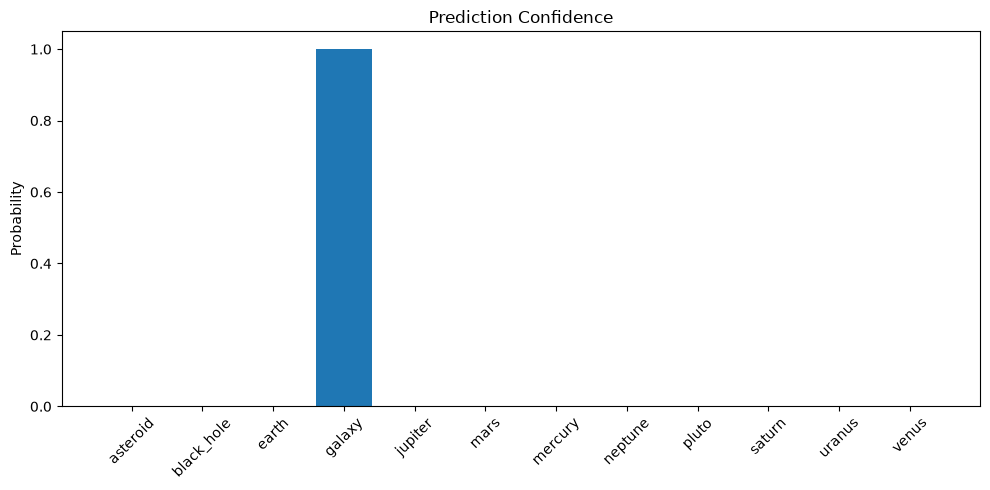

In [24]:
plt.figure(figsize=(10,5))
plt.bar(
    CLASS_NAMES,
    probabilities.cpu().numpy()[0]
)
plt.xticks(rotation=45)
plt.ylabel("Probability")
plt.title("Prediction Confidence")
plt.tight_layout()
plt.show()

# Conclusion

## Objective
To perform inference on unseen astronomy images using the trained CNN model.

## What We Did
- Loaded the trained CNN model.
- Loaded unseen input images.
- Applied preprocessing transforms.
- Generated predictions.
- Calculated confidence scores.
- Displayed Top-5 predicted classes.

## Results
- Successfully classified unseen astronomy images.
- Produced confidence scores using Softmax.
- Generated Top-5 class predictions.

## Key Learnings
- Model deployment workflow.
- Image preprocessing consistency.
- Softmax probabilities.
- Confidence estimation.
- Practical inference pipeline.

## Conclusion
The inference pipeline demonstrated that the trained CNN can accurately classify previously unseen astronomy images and provide interpretable confidence scores.